In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
X, Y = make_moons(
    n_samples=600,
    random_state=42,
    noise=0.25
)

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [8]:
y_test

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1])

# Pre-Pruning (Early Stopping)

In [11]:
depths = list(range(1,15))
train_acc_pre = []
test_acc_pre = []

for d in depths:
    tree = DecisionTreeClassifier(
        max_depth=d,
        min_samples_leaf=5,
        random_state=42
    )

    tree.fit(x_train, y_train)

    train_acc_pre.append(
        accuracy_score(y_train, tree.predict(x_train))
    )

    test_acc_pre.append(
        accuracy_score(y_test, tree.predict(x_test))
    )

test_acc_pre

[0.8111111111111111,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9]

Text(0, 0.5, 'Accuracy')

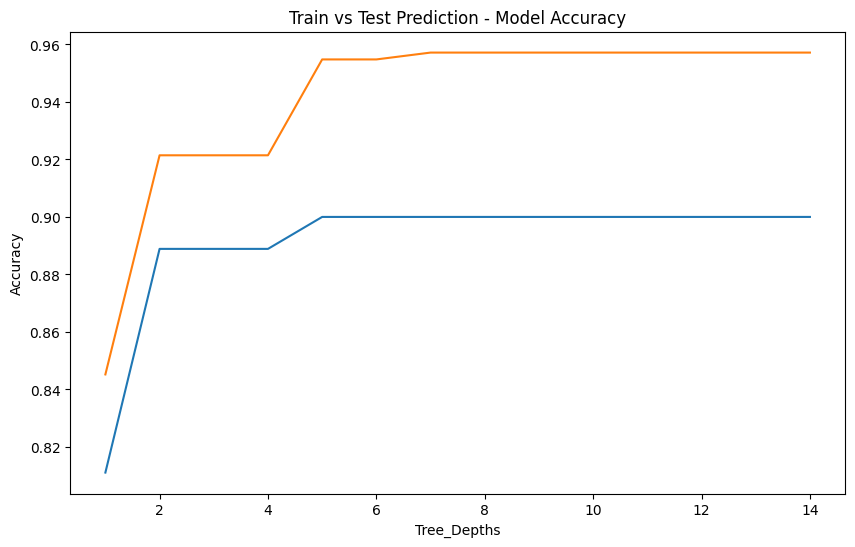

In [23]:
plt.figure(figsize=(10,6))
plt.title('Train vs Test Prediction - Model Accuracy')
plt.plot(depths, test_acc_pre, label='Test_Accuracy')
plt.plot(depths, train_acc_pre, label='Train_Accuracy')
plt.xlabel('Tree_Depths')
plt.ylabel('Accuracy')

# Post-Pruning (Cost Complex Pruning)

In [21]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train, y_train)

path = full_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alpha = path.ccp_alphas

train_acc_post = []
test_acc_post = []

for alpha in ccp_alpha:
    pruned_tree = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    pruned_tree.fit(x_train, y_train)

    train_acc_post.append(
        accuracy_score(y_train, pruned_tree.predict(x_train))
    )

    test_acc_post.append(
        accuracy_score(y_test, pruned_tree.predict(x_test))
    )

test_acc_post

[0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9111111111111111,
 0.9111111111111111,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.9,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.8611111111111112,
 0.8111111111111111,
 0.49444444444444446]

Text(0, 0.5, 'Accuracy')

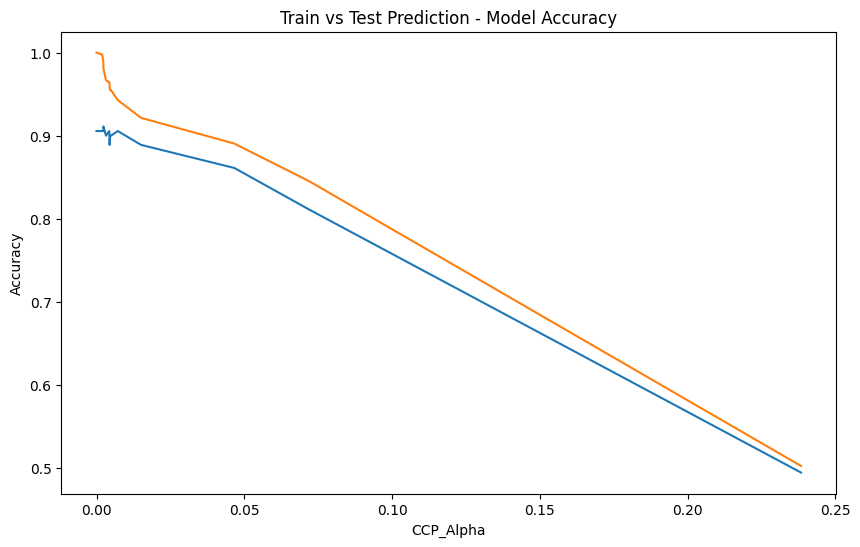

In [24]:
plt.figure(figsize=(10,6))
plt.title('Train vs Test Prediction - Model Accuracy')
plt.plot(ccp_alpha, test_acc_post, label='Test_Accuracy')
plt.plot(ccp_alpha, train_acc_post, label='Train_Accuracy')
plt.xlabel('CCP_Alpha')
plt.ylabel('Accuracy')

In [25]:
path

{'ccp_alphas': array([0.        , 0.00190476, 0.00227743, 0.00227743, 0.00230811,
        0.00233083, 0.00233641, 0.00321429, 0.004329  , 0.00443673,
        0.00459661, 0.00490909, 0.00718846, 0.01507148, 0.04662934,
        0.07192859, 0.23840256]),
 'impurities': array([0.        , 0.00380952, 0.01291925, 0.01747412, 0.02209033,
        0.03141364, 0.03608645, 0.04894359, 0.0532726 , 0.06214605,
        0.07133928, 0.07624837, 0.09781374, 0.14302817, 0.18965751,
        0.26158611, 0.49998866])}